In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN,Bidirectional,Dropout,LayerNormalization,Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


import bz2
import re
import csv

In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
# Read training file line by line
train_data = []

with open("train.ft.txt", "r", encoding="utf-8") as file:
    for i, line in enumerate(file):
        if i >= 50000:      # Keep only first 250k
            break
        train_data.append(line.strip())

In [4]:
# Read testing file line by line
test_data = []

with open("test.ft.txt", "r", encoding="utf-8") as file:
    for i, line in enumerate(file):
        if i >= 30000:       # Keep only first 40k
            break
        test_data.append(line.strip())

In [5]:
print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 50000
Testing samples: 30000


Preparaing Dataset


In [6]:

training_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in train_data]

training_texts = [re.sub(r'__label__\d\s+', '', line) for line in train_data]
for i in range(len(training_labels)):
    if training_labels[i] == 1:
        training_labels[i] = 0
    else:
        training_labels[i] = 1

In [7]:

test_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in test_data]

test_texts = [re.sub(r'__label__\d\s+', '', line) for line in test_data]
for i in range(len(test_labels)):
    if test_labels[i] == 1:
        test_labels[i] = 0
    else:
        test_labels[i] = 1

cleaning texts

In [8]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASHVITA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)



training_texts = [clean_text(text) for text in training_texts]
test_texts = [clean_text(text) for text in test_texts]

In [10]:
training_texts[0]

'stune even non gamer sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen'

Tokenization

In [11]:
max_words = 1000
max_sequence_length = 150
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(training_texts)

X_train =tokenizer.texts_to_sequences(training_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train,maxlen= max_sequence_length)
X_test = pad_sequences(X_test,maxlen= max_sequence_length)

In [12]:
X_train[:5]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  20, 554,  79, 191, 167, 271,  17,  10,  20,  51, 351,
        102,  39,  57, 102, 102,  47,  57,  23,  39,  55, 173,  70, 757,
        776, 719,  10, 444, 118, 254, 111],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
       

In [13]:
 X_train=np.array(X_train)
 print(X_train.shape)
 X_test=np.array(X_test)
 print(X_test.shape)
 y_train = np.array(training_labels)
 print(y_train.shape)
 y_test = np.array(test_labels)
 print(y_test.shape)

(50000, 150)
(30000, 150)
(50000,)
(30000,)


Training RNN

In [14]:
model = Sequential([
    Embedding(input_dim=max_words,output_dim=100,input_length=max_sequence_length),
    SimpleRNN(64,return_sequences=True,dropout=0.3),
    LayerNormalization(),
    SimpleRNN(64,dropout=0.3),
    LayerNormalization(),
    Dropout(0.3),
    Dense(64,activation = "relu"),
    Dropout(0.2),
    Dense(1,activation = "sigmoid")
])


model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=5e-5),
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

c:\Users\ASHVITA\Desktop\Sentiment_Analysis\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 71s 612ms/step - accuracy: 0.5064 - loss: 0.8033 - val_accuracy: 0.5010 - val_loss: 0.7124
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 532ms/step - accuracy: 0.5058 - loss: 0.7638 - val_accuracy: 0.5025 - val_loss: 0.6972
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 55s 568ms/step - accuracy: 0.5051 - loss: 0.7385 - val_accuracy: 0.5200 - val_loss: 0.6926
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 548ms/step - accuracy: 0.5054 - loss: 0.7254 - val_accuracy: 0.5250 - val_loss: 0.6918
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 614ms/step - accuracy: 0.5059 - loss: 0.7161 - val_accuracy: 0.5213 - val_loss: 0.6921
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 59s 599ms/step - accuracy: 0.5122 - loss: 0.7100 - val_accuracy: 0.5205 - val_loss: 0.6917
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 69s 703ms/step - accuracy: 0.5138 - loss: 0.7068 - val_accuracy: 0.5342 - val_loss: 0.6895
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 605ms/step - accuracy: 0.5234 - loss: 0.6998 - val_accu

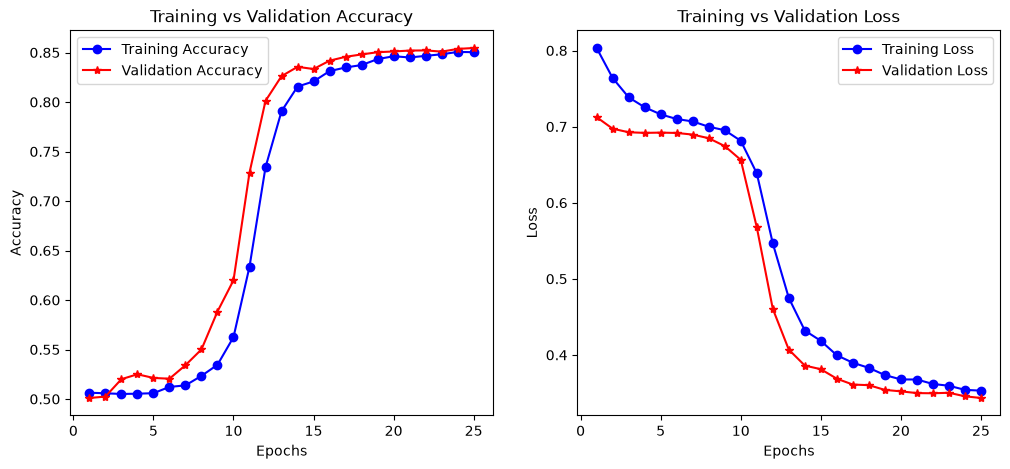

In [15]:
# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [16]:
#metrics
y_pred = model.predict(X_test)
y_pred = (y_pred>0.5)

cm = confusion_matrix(y_test,y_pred)
print(cm)
report = classification_report(y_test,y_pred)
print(report)

938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step
[[12238  2429]
 [ 1934 13399]]
              precision    recall  f1-score   support

           0       0.86      0.83      0.85     14667
           1       0.85      0.87      0.86     15333

    accuracy                           0.85     30000
   macro avg       0.86      0.85      0.85     30000
weighted avg       0.85      0.85      0.85     30000



In [17]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text, model, tokenizer, max_sequence_length=100):

    text = clean_text(text)

    sequence = tokenizer.texts_to_sequences([text])


    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)


    prediction = model.predict(padded_sequence)[0][0]


    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😡"

    return sentiment, float(prediction)

test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
    print(f"Text: {sentence}\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.4f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
Text: I love this product! It's amazing.
Predicted Sentiment: Positive 😊 (Confidence: 0.7223)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Text: This is the worst service I have ever experienced.
Predicted Sentiment: Negative 😡 (Confidence: 0.1607)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Text: The movie was okay, not great but not terrible either.
Predicted Sentiment: Negative 😡 (Confidence: 0.1996)



In [22]:
import pickle

with open("models/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [23]:
import pickle

with open("models/model.pkl", "rb") as f:
    model = pickle.load(f)

In [19]:
import pickle

with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)